# PharmaOps-AI

# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform exploratory data analysis on the pharmacy datasets to understand inventory, medicines, suppliers, sales, and waste patterns. The insights generated will support feature engineering, business analytics, Power BI dashboards, and AI-driven recommendations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
medicines_df = pd.read_csv("../../data/processed/python/Medicines.csv")

inventory_df = pd.read_csv("../../data/processed/python/Inventory.csv")

suppliers_df = pd.read_csv("../../data/processed/python/Suppliers.csv")

sales_df = pd.read_csv("../../data/processed/python/Sales.csv")

waste_df = pd.read_csv("../../data/processed/python/Waste.csv")

category_df = pd.read_csv("../../data/processed/python/Category.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
inventory_master = inventory_df.merge(
    medicines_df,
    on="Medicine_ID",
    how="left"
)

inventory_master = inventory_master.merge(
    suppliers_df,
    on="Supplier_ID",
    how="left"
)

inventory_master = inventory_master.merge(
    category_df,
    on="Category_ID",
    how="left"
)

print(inventory_master.shape)

(4954, 40)


In [4]:
sales_master = sales_df.merge(
    medicines_df,
    on="Medicine_ID",
    how="left"
)

sales_master = sales_master.merge(
    category_df,
    on="Category_ID",
    how="left"
)

print(sales_master.shape)

(9901, 27)


In [5]:
waste_master = waste_df.merge(
    medicines_df,
    on="Medicine_ID",
    how="left"
)

waste_master = waste_master.merge(
    category_df,
    on="Category_ID",
    how="left"
)

print(waste_master.shape)

(2481, 27)


In [7]:
from pathlib import Path

base_output = Path("../../outputs/charts")

folders = [
    "inventory",
    "sales",
    "waste",
    "medicines",
    "supplier",
    "category",
    "correlation",
    "executive"
]

for folder in folders:
    (base_output / folder).mkdir(parents=True, exist_ok=True)

print("Output folders created successfully.")

Output folders created successfully.


# Inventory Analytics

This section analyzes inventory availability, stock health, warehouse distribution, inventory valuation, and reorder patterns to identify inventory optimization opportunities.

## Chart 1: Stock Status Distribution

### Business Objective

Analyze the distribution of inventory records across different stock status categories to assess inventory health.

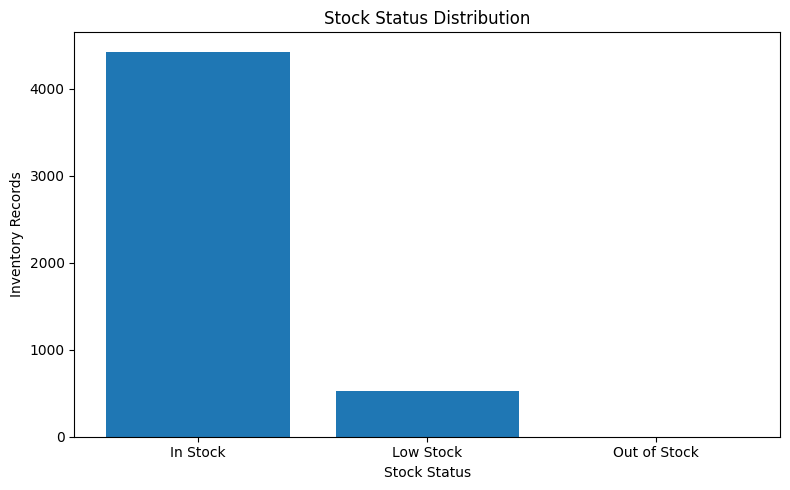

In [8]:
stock_status = inventory_master["Stock_Status"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    stock_status.index,
    stock_status.values
)

plt.title("Stock Status Distribution")
plt.xlabel("Stock Status")
plt.ylabel("Inventory Records")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/inventory/01_Stock_Status_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

### Business Observation

- Provides a snapshot of overall inventory health.
- Highlights medicines that are adequately stocked, running low, or out of stock.
- Helps prioritize inventory replenishment and reduce stockout risks.

## Chart 2: Inventory Value by Category

### Business Objective

Evaluate inventory investment across different medicine categories to identify high-value inventory segments.

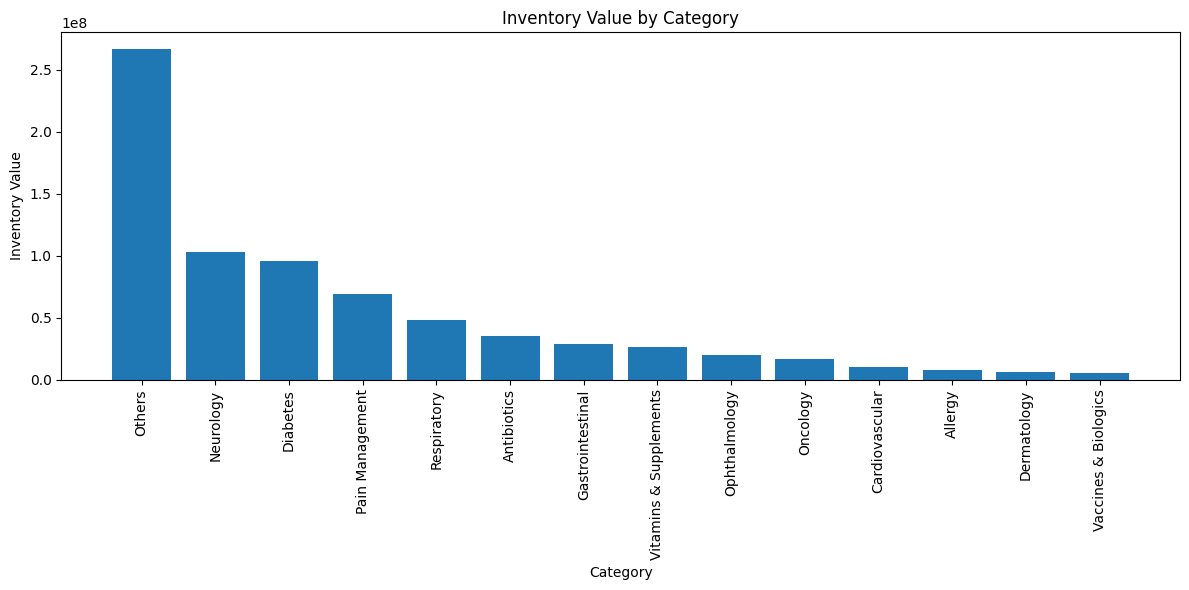

In [9]:
inventory_master["Inventory_Value"] = (
    inventory_master["Quantity_In_Stock"] *
    inventory_master["Unit_Cost"]
)

category_value = (
    inventory_master
    .groupby("Category_Name")["Inventory_Value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    category_value.index,
    category_value.values
)

plt.xticks(rotation=90)

plt.title("Inventory Value by Category")
plt.xlabel("Category")
plt.ylabel("Inventory Value")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/inventory/02_Inventory_Value_by_Category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

### Business Observation

- Identifies medicine categories requiring the highest inventory investment.
- Supports procurement optimization and working capital planning.
- Helps management balance inventory costs across categories.

## Chart 3: Top 10 Medicines by Inventory Quantity

### Business Objective

Identify medicines with the highest inventory levels to detect potential overstocking and optimize inventory allocation.

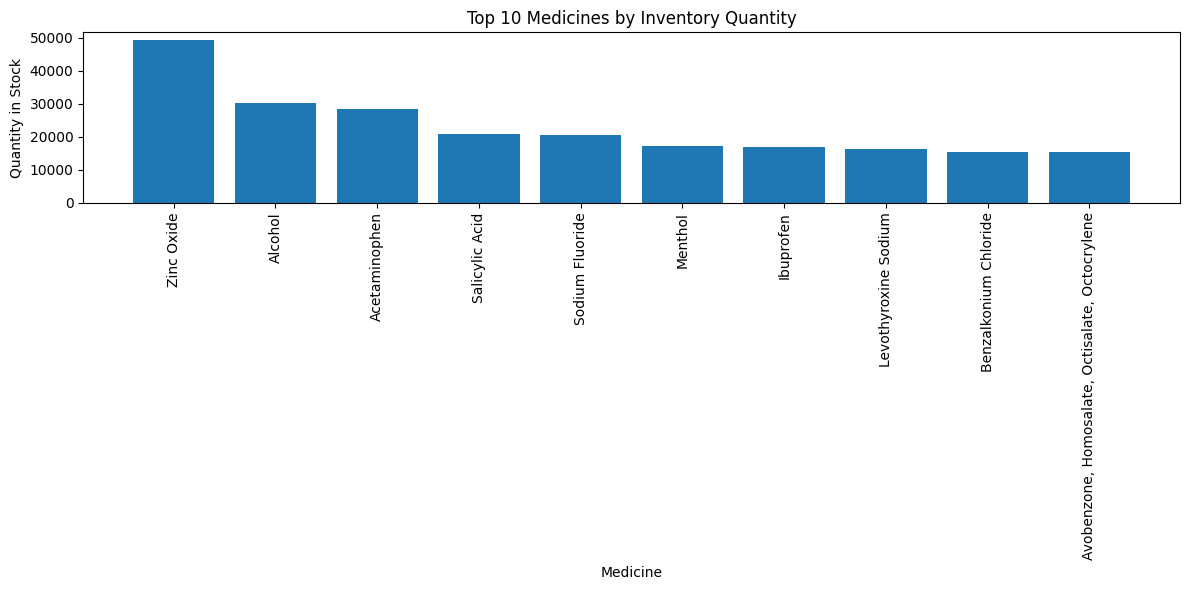

In [10]:
top_inventory = (
    inventory_master
    .groupby("Generic_Name")["Quantity_In_Stock"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(top_inventory.index, top_inventory.values)

plt.title("Top 10 Medicines by Inventory Quantity")
plt.xlabel("Medicine")
plt.ylabel("Quantity in Stock")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/inventory/03_Top_10_Medicines_by_Inventory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Identifies medicines occupying the largest inventory space.
- Helps detect overstocked products.
- Supports inventory balancing and warehouse optimization.

## Chart 4: Warehouse Inventory Distribution

### Business Objective

Analyze how inventory is distributed across warehouse locations.

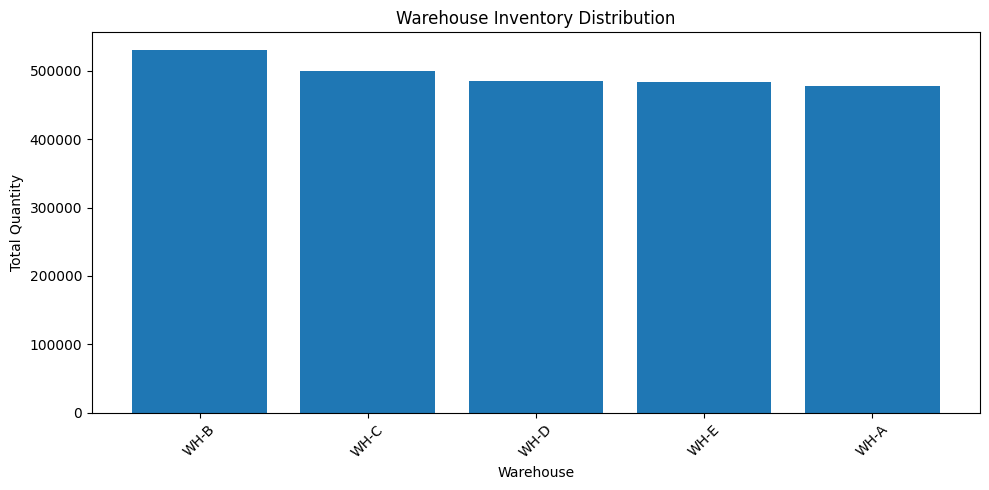

In [11]:
warehouse_stock = (
    inventory_master
    .groupby("Warehouse_Location")["Quantity_In_Stock"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(
    warehouse_stock.index,
    warehouse_stock.values
)

plt.title("Warehouse Inventory Distribution")
plt.xlabel("Warehouse")
plt.ylabel("Total Quantity")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/inventory/04_Warehouse_Inventory_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Highlights warehouse-wise inventory allocation.
- Helps identify overloaded or underutilized warehouses.
- Supports warehouse capacity planning.

## Chart 5: Inventory Value Distribution

### Business Objective

Understand the distribution of inventory values across inventory records.

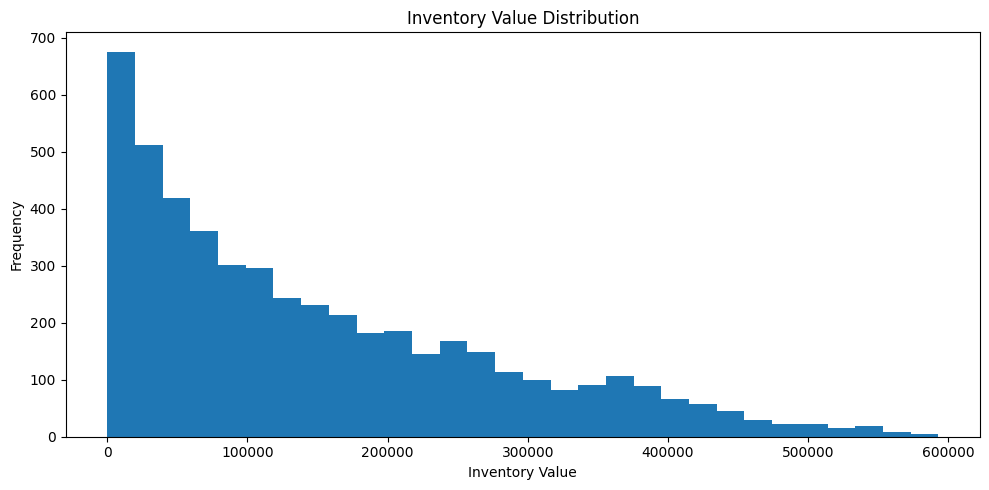

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    inventory_master["Inventory_Value"],
    bins=30
)

plt.title("Inventory Value Distribution")
plt.xlabel("Inventory Value")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/inventory/05_Inventory_Value_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows how inventory investment is distributed.
- Identifies expensive inventory batches.
- Helps evaluate inventory carrying costs.

## Chart 6: Reorder Level Distribution

### Business Objective

Analyze reorder thresholds maintained for inventory items.

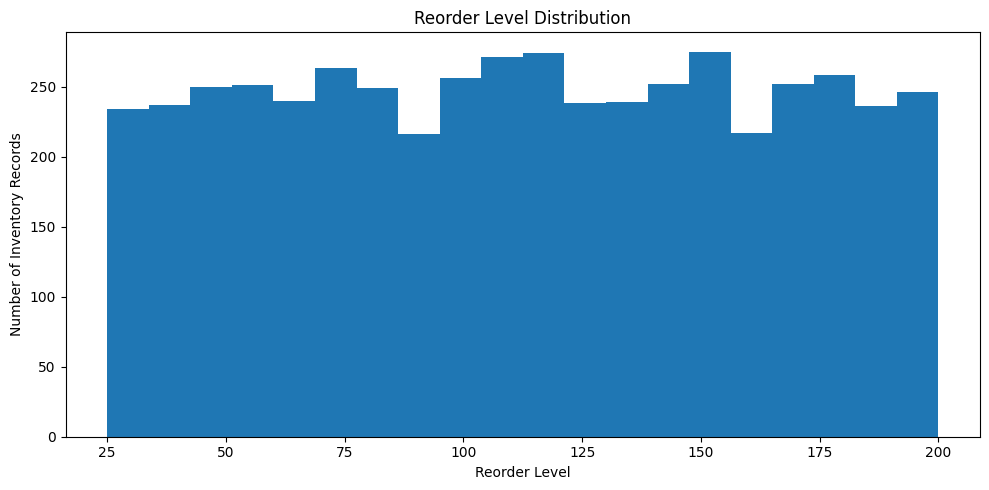

In [15]:
plt.figure(figsize=(10,5))

plt.hist(
    inventory_master["Reorder_Level"],
    bins=20
)

plt.title("Reorder Level Distribution")
plt.xlabel("Reorder Level")
plt.ylabel("Number of Inventory Records")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/inventory/06_Reorder_Level_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Evaluates inventory replenishment thresholds.
- Helps identify unusually low or high reorder levels.
- Supports inventory planning and stock optimization.

## Chart 7: Unit Cost Distribution

### Business Objective

Analyze the pricing distribution of medicines based on their unit cost.

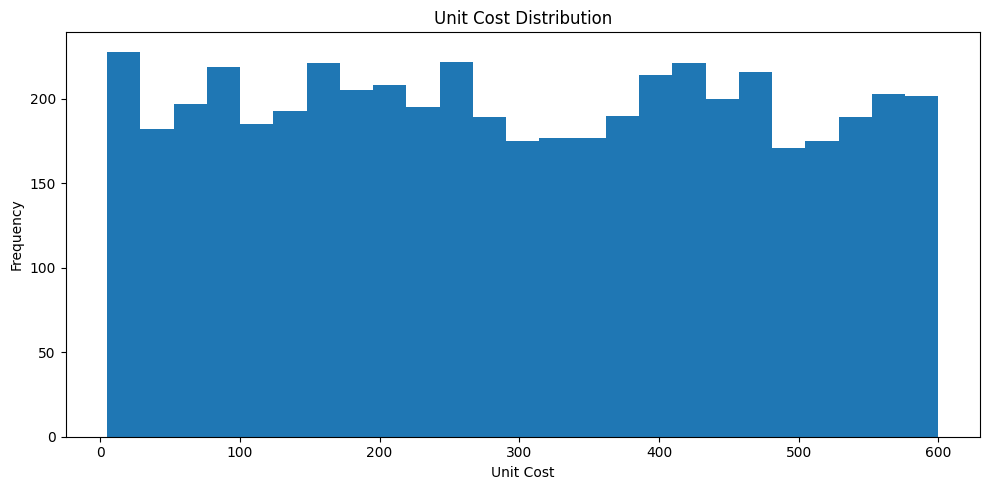

In [16]:
plt.figure(figsize=(10,5))

plt.hist(
    inventory_master["Unit_Cost"],
    bins=25
)

plt.title("Unit Cost Distribution")
plt.xlabel("Unit Cost")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/inventory/07_Unit_Cost_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows the distribution of medicine procurement costs.
- Helps identify low-cost and high-cost inventory items.
- Supports procurement budgeting and pricing analysis.

# Sales Analytics

This section analyzes pharmacy sales performance by examining revenue trends, customer purchasing behavior, payment preferences, medicine performance, and category-wise sales. The insights generated help evaluate business growth, identify high-performing products, and support strategic sales decisions.

## Chart 8: Monthly Revenue Trend

### Business Objective

Analyze monthly revenue trends to identify seasonal patterns and monitor overall business performance.

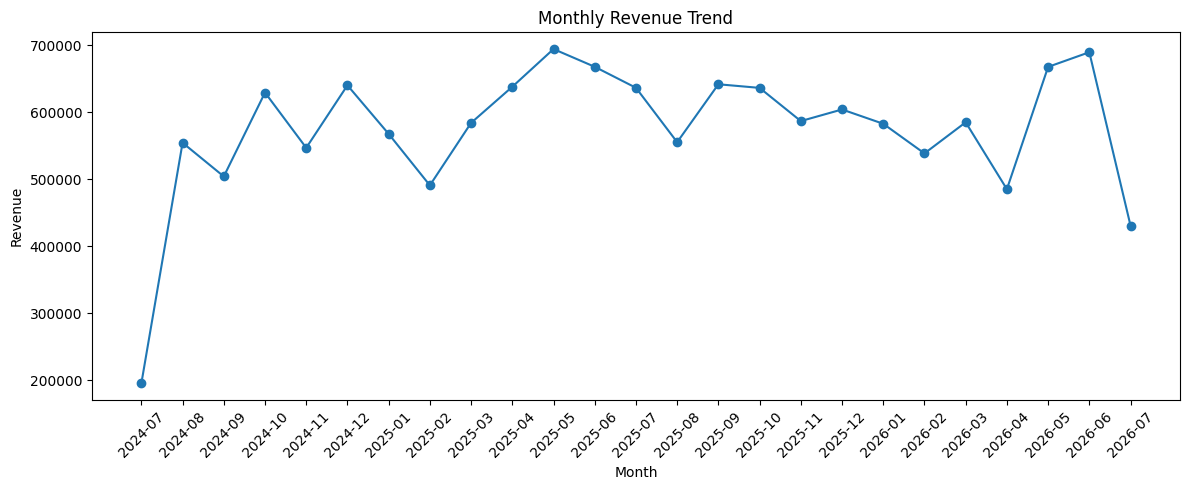

In [18]:
sales_master["Transaction_Date"] = pd.to_datetime(
    sales_master["Transaction_Date"]
)

monthly_sales = (
    sales_master
    .groupby(
        sales_master["Transaction_Date"].dt.to_period("M")
    )["Total_Amount"]
    .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/sales/08_Monthly_Revenue_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows overall revenue growth across months.
- Helps identify seasonal demand patterns.
- Supports sales forecasting and inventory planning.

## Chart 9: Revenue by Medicine Category

### Business Objective

Identify which medicine categories generate the highest revenue.

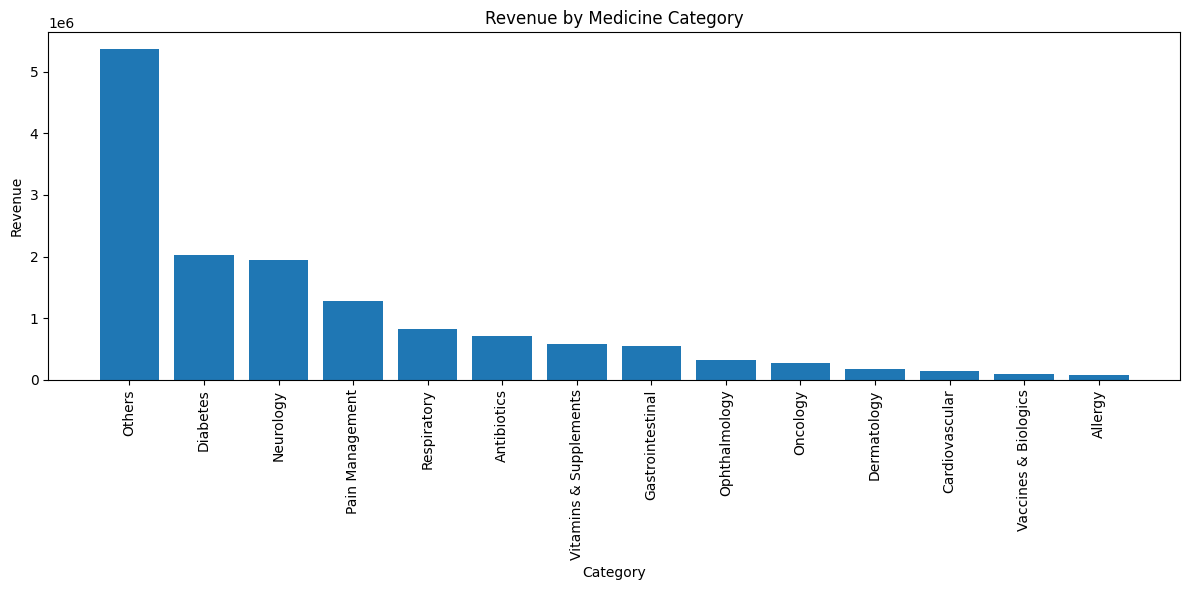

In [19]:
category_sales = (
    sales_master
    .groupby("Category_Name")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.xticks(rotation=90)

plt.title("Revenue by Medicine Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/sales/09_Revenue_by_Category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Identifies the highest revenue-generating medicine categories.
- Supports product portfolio optimization.
- Helps prioritize procurement budgets.

## Chart 10: Payment Method Distribution

### Business Objective

Analyze customer payment preferences across pharmacy transactions.

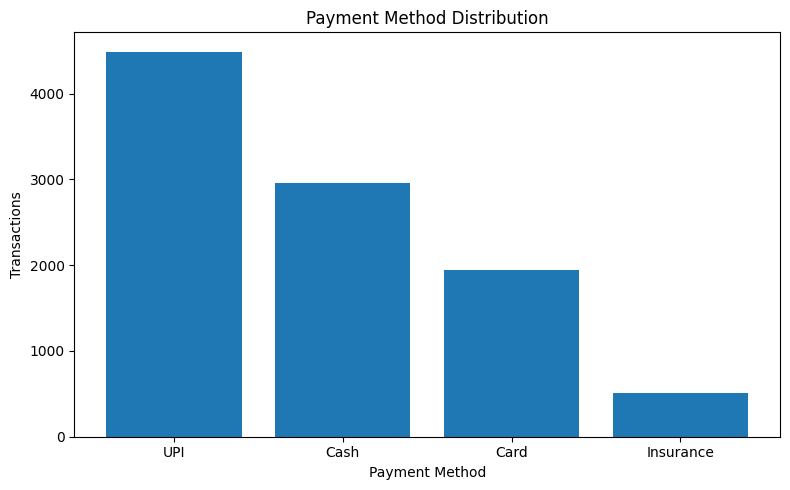

In [20]:
payment = sales_master["Payment_Method"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    payment.index,
    payment.values
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Transactions")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/sales/10_Payment_Method_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Highlights the most frequently used payment methods.
- Supports digital payment adoption analysis.
- Helps optimize payment infrastructure.

## Chart 11: Customer Type Distribution

### Business Objective

Understand purchasing behavior across different customer segments.

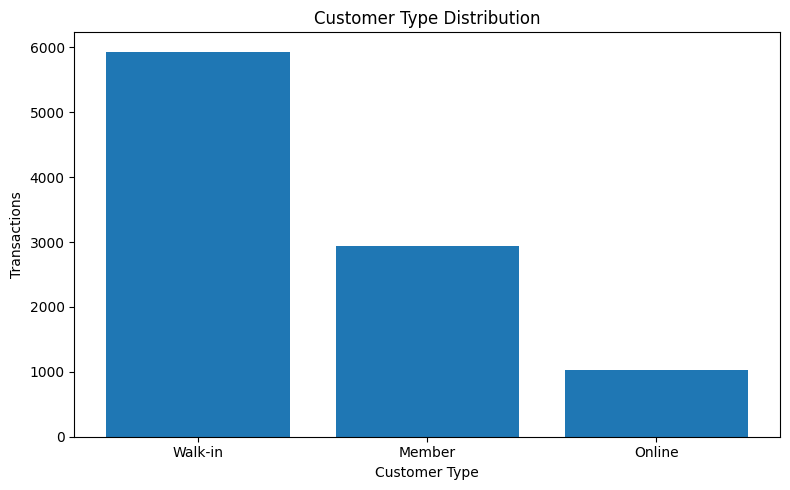

In [21]:
customer = sales_master["Customer_Type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    customer.index,
    customer.values
)

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Transactions")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/sales/11_Customer_Type_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows contribution of each customer segment.
- Helps understand customer purchasing patterns.
- Supports targeted marketing initiatives.

## Chart 12: Discount Distribution

### Business Objective

Analyze how discounts are applied across pharmacy transactions.

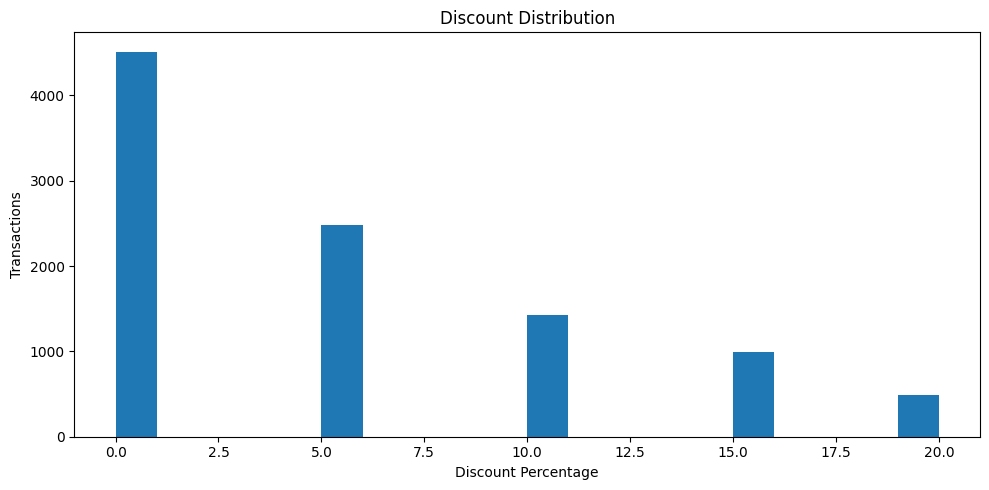

In [22]:
plt.figure(figsize=(10,5))

plt.hist(
    sales_master["Discount_Percentage"],
    bins=20
)

plt.title("Discount Distribution")
plt.xlabel("Discount Percentage")
plt.ylabel("Transactions")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/sales/12_Discount_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows the frequency of discount utilization.
- Helps evaluate promotional strategies.
- Supports pricing optimization.

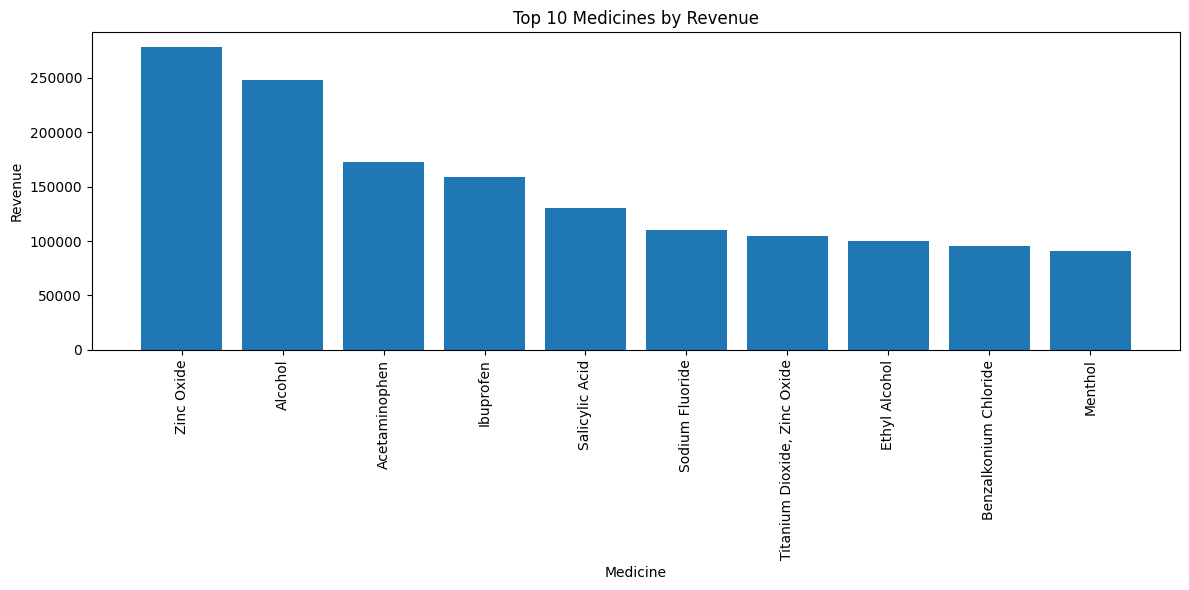

In [23]:
top_revenue = (
    sales_master
    .groupby("Generic_Name")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_revenue.index,
    top_revenue.values
)

plt.xticks(rotation=90)

plt.title("Top 10 Medicines by Revenue")
plt.xlabel("Medicine")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/sales/13_Top_10_Medicines_by_Revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Identifies the highest revenue-generating medicines.
- Supports inventory prioritization.
- Helps optimize medicine assortment and profitability.

## Chart 14: Prescription vs Non-Prescription Sales

### Business Objective

Compare sales transactions that require prescriptions with those that do not.

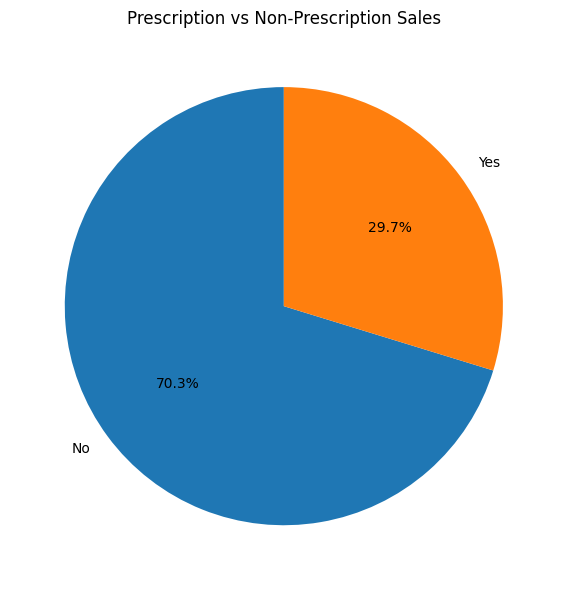

In [24]:
prescription = sales_master["Prescription_Required"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    prescription.values,
    labels=prescription.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Prescription vs Non-Prescription Sales")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/sales/14_Prescription_vs_NonPrescription.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Measures the proportion of prescription-based and over-the-counter sales.
- Helps assess regulatory compliance.
- Supports medicine demand planning and pharmacy operations.

# Waste Analytics

This section evaluates medicine waste patterns by analyzing waste value, disposal methods, expiry-related losses, and category-wise waste trends. The insights help reduce financial losses, improve inventory planning, and strengthen waste management practices.

## Chart 15: Waste Value by Medicine Category

### Business Objective

Identify medicine categories contributing the highest financial loss due to waste.

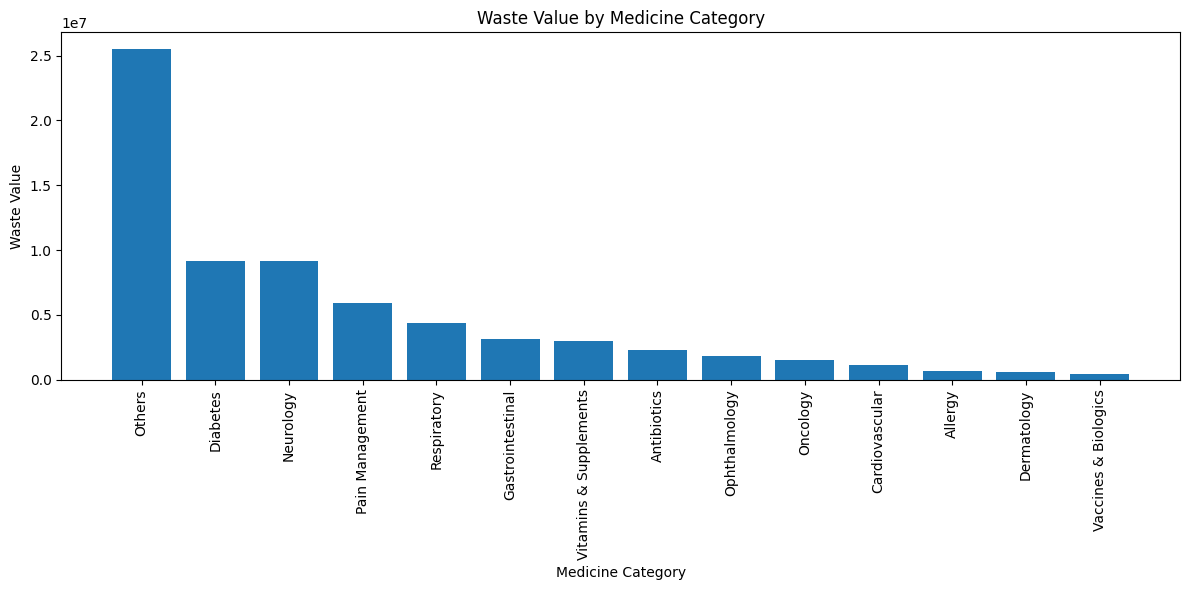

In [25]:
waste_category = (
    waste_master
    .groupby("Category_Name")["Total_Waste_Value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    waste_category.index,
    waste_category.values
)

plt.xticks(rotation=90)

plt.title("Waste Value by Medicine Category")
plt.xlabel("Medicine Category")
plt.ylabel("Waste Value")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/waste/15_Waste_Value_by_Category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Identifies medicine categories generating the highest financial waste.
- Supports inventory optimization and procurement planning.
- Helps prioritize waste reduction initiatives.

## Chart 16: Waste Reasons Distribution

### Business Objective

Analyze the major reasons behind medicine waste.

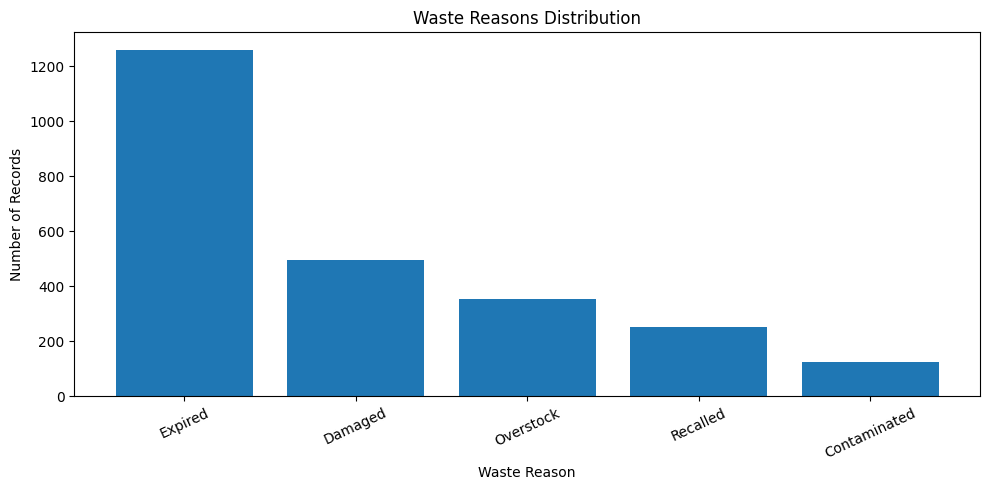

In [26]:
waste_reason = (
    waste_master["Waste_Reason"]
    .value_counts()
)

plt.figure(figsize=(10,5))

plt.bar(
    waste_reason.index,
    waste_reason.values
)

plt.title("Waste Reasons Distribution")
plt.xlabel("Waste Reason")
plt.ylabel("Number of Records")

plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/waste/16_Waste_Reasons_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Highlights the primary causes of medicine waste.
- Helps management focus on preventable waste factors.
- Supports continuous quality improvement.

## Chart 17: Disposal Method Distribution

### Business Objective

Evaluate the methods used for disposing of pharmaceutical waste.

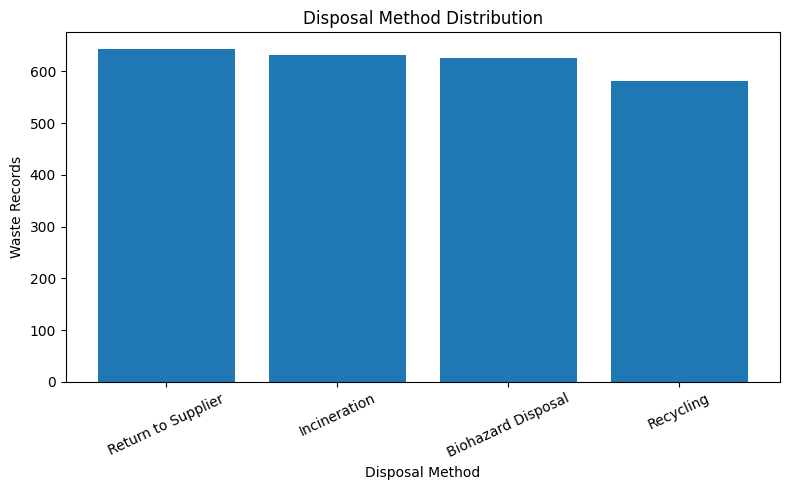

In [27]:
disposal = (
    waste_master["Disposal_Method"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    disposal.index,
    disposal.values
)

plt.title("Disposal Method Distribution")
plt.xlabel("Disposal Method")
plt.ylabel("Waste Records")

plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/waste/17_Disposal_Method_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows the preferred disposal methods.
- Helps monitor regulatory compliance.
- Supports sustainable waste management.

## Chart 18: Monthly Waste Trend

### Business Objective

Monitor changes in pharmaceutical waste over time.

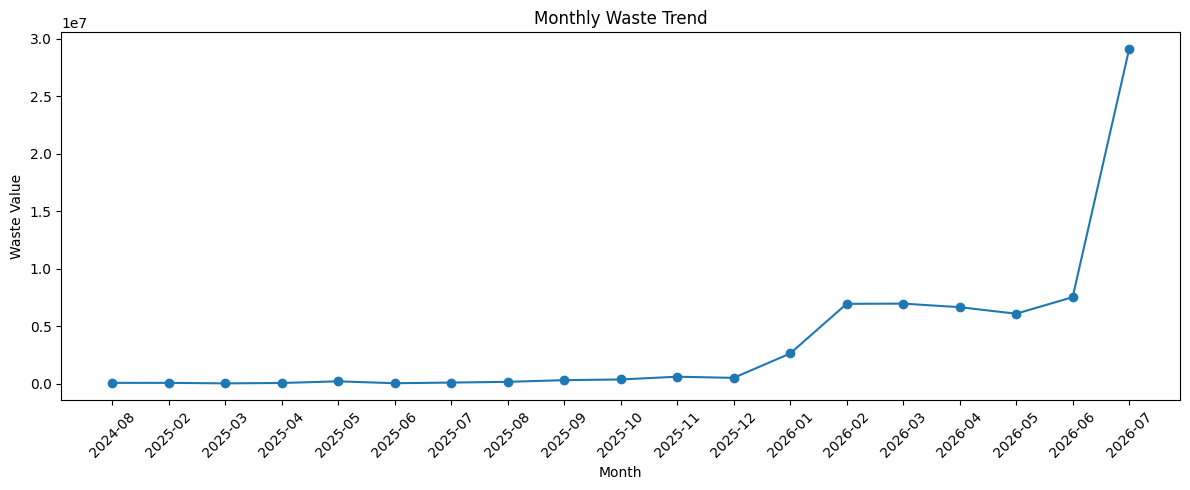

In [28]:
waste_master["Waste_Date"] = pd.to_datetime(
    waste_master["Waste_Date"]
)

monthly_waste = (
    waste_master
    .groupby(
        waste_master["Waste_Date"].dt.to_period("M")
    )["Total_Waste_Value"]
    .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_waste.index.astype(str),
    monthly_waste.values,
    marker="o"
)

plt.title("Monthly Waste Trend")
plt.xlabel("Month")
plt.ylabel("Waste Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/waste/18_Monthly_Waste_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Tracks monthly fluctuations in medicine waste.
- Identifies periods with unusually high waste.
- Supports proactive inventory planning.

## Chart 19: Top 10 Medicines by Waste Value

### Business Objective

Identify medicines contributing the highest financial waste.

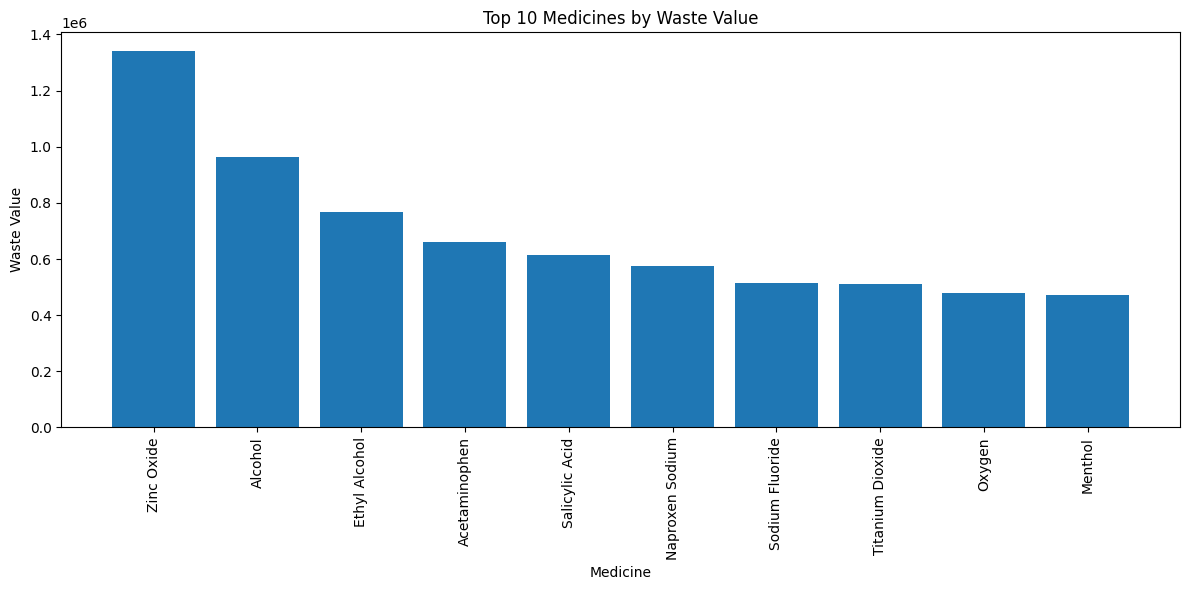

In [29]:
top_waste = (
    waste_master
    .groupby("Generic_Name")["Total_Waste_Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_waste.index,
    top_waste.values
)

plt.xticks(rotation=90)

plt.title("Top 10 Medicines by Waste Value")
plt.xlabel("Medicine")
plt.ylabel("Waste Value")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/waste/19_Top_10_Medicines_by_Waste_Value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Highlights medicines causing the greatest financial loss.
- Supports better stock rotation and expiry management.
- Helps reduce inventory waste.

## Chart 20: Waste Quantity Distribution

### Business Objective

Analyze the distribution of quantities wasted across all waste records.

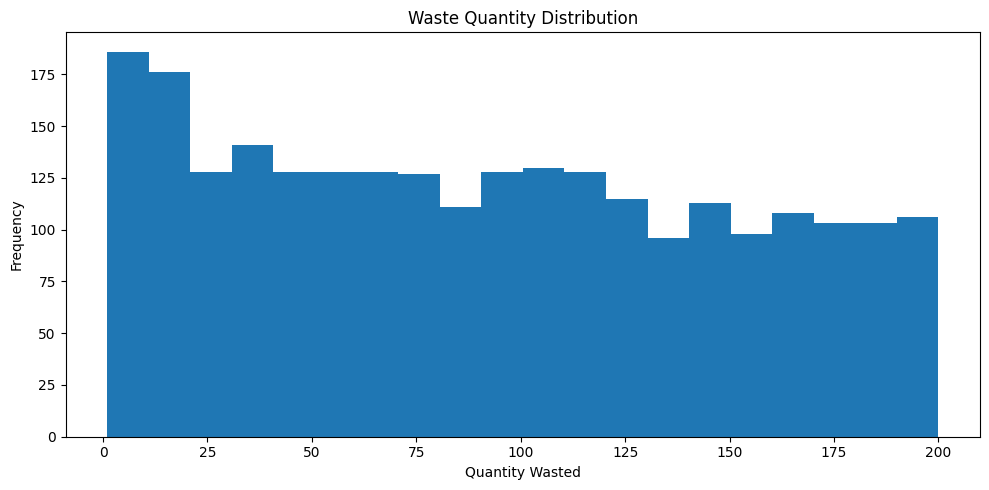

In [30]:
plt.figure(figsize=(10,5))

plt.hist(
    waste_master["Quantity_Wasted"],
    bins=20
)

plt.title("Waste Quantity Distribution")
plt.xlabel("Quantity Wasted")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/waste/20_Waste_Quantity_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows the frequency of different waste quantities.
- Helps identify unusually large waste events.
- Supports waste reduction initiatives.

## Chart 21: Disposal Status Distribution

### Business Objective

Evaluate the current status of pharmaceutical waste disposal activities.

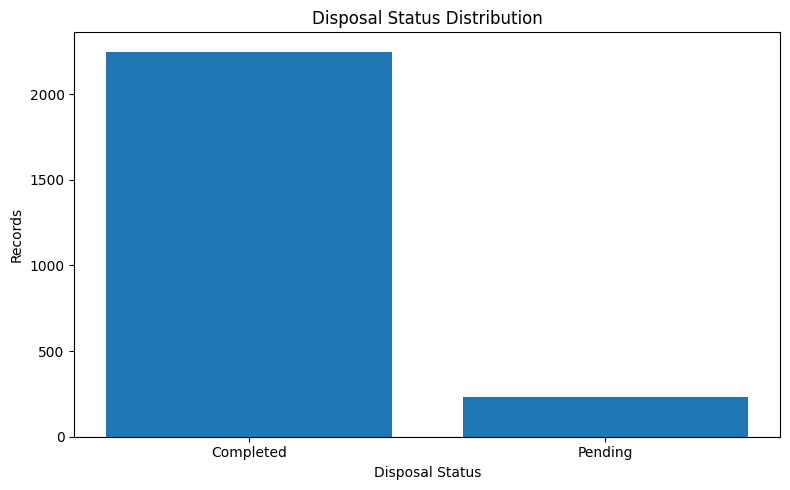

In [31]:
status = (
    waste_master["Disposal_Status"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    status.index,
    status.values
)

plt.title("Disposal Status Distribution")
plt.xlabel("Disposal Status")
plt.ylabel("Records")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/waste/21_Disposal_Status_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Monitors the completion status of waste disposal activities.
- Supports compliance tracking and operational monitoring.
- Helps ensure timely disposal of pharmaceutical waste.

# Medicine Analytics

This section explores the composition of the medicine catalog by analyzing dosage forms, routes of administration, manufacturers, pharmacological classes, and medicine strengths. The insights support product portfolio management, supplier planning, and inventory optimization.

## Chart 22: Dosage Form Distribution

### Business Objective

Analyze the distribution of medicines across different dosage forms to understand the composition of the product portfolio.

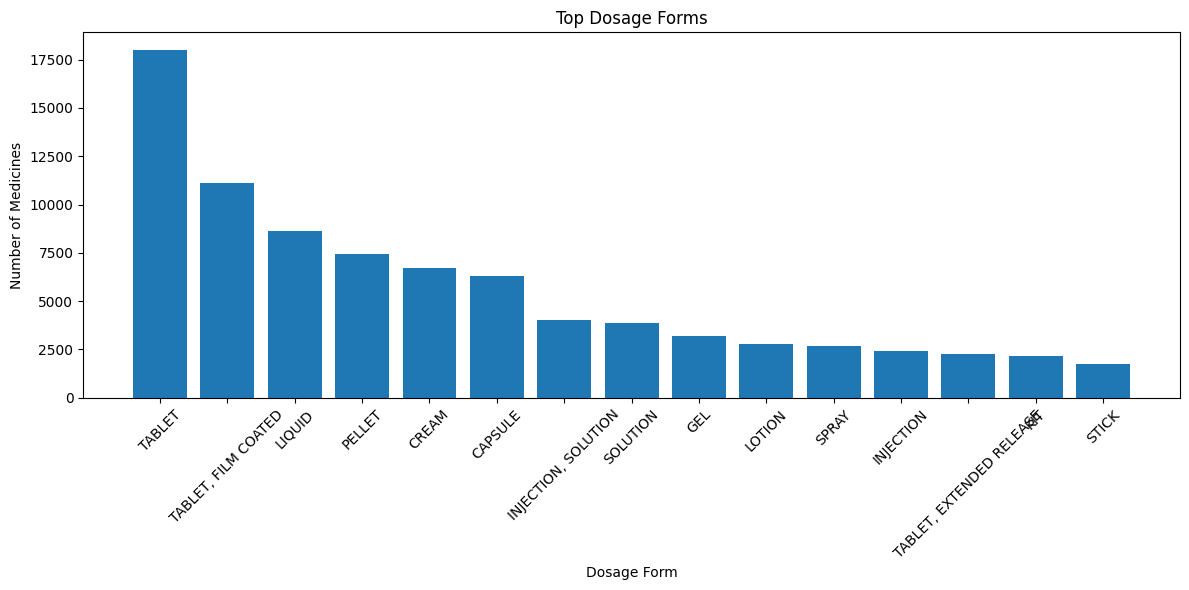

In [32]:
dosage = (
    medicines_df["Dosage_Form"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

plt.bar(
    dosage.index,
    dosage.values
)

plt.title("Top Dosage Forms")
plt.xlabel("Dosage Form")
plt.ylabel("Number of Medicines")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/medicines/22_Dosage_Form_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Highlights the most commonly available dosage forms.
- Helps evaluate product portfolio composition.
- Supports demand forecasting and inventory planning.

## Chart 23: Route of Administration Distribution

### Business Objective

Analyze medicines based on their route of administration.

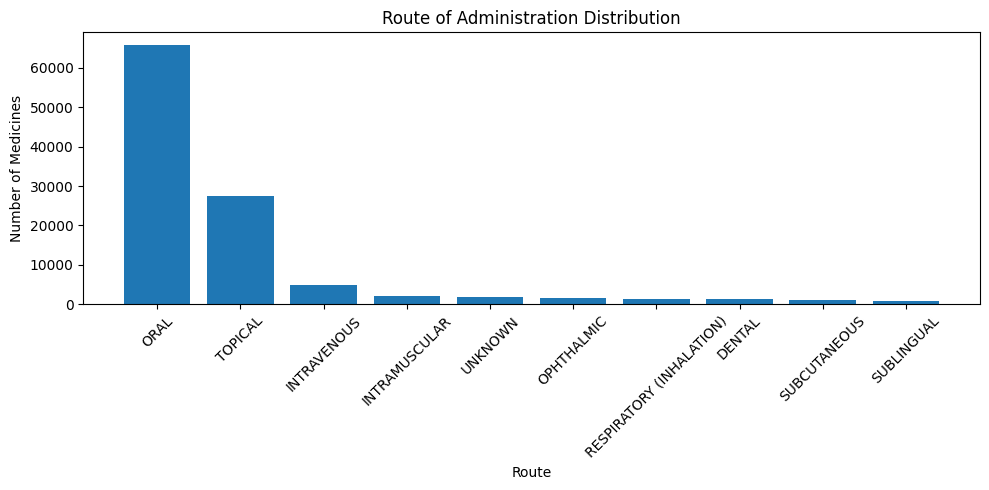

In [33]:
route = (
    medicines_df["Route"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    route.index,
    route.values
)

plt.title("Route of Administration Distribution")
plt.xlabel("Route")
plt.ylabel("Number of Medicines")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/medicines/23_Route_of_Administration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows the dominant administration routes.
- Helps understand the product mix.
- Supports procurement and storage planning.

## Chart 24: Top 15 Manufacturers

### Business Objective

Identify manufacturers contributing the largest number of medicines.

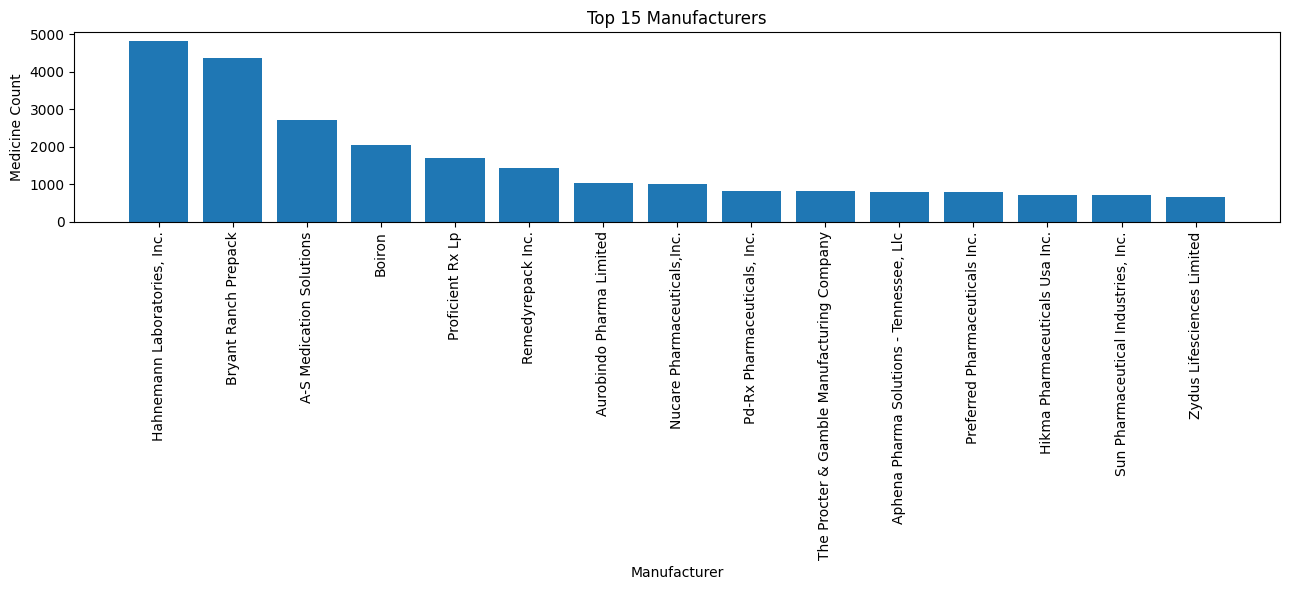

In [34]:
manufacturers = (
    medicines_df["Manufacturer"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(13,6))

plt.bar(
    manufacturers.index,
    manufacturers.values
)

plt.title("Top 15 Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Medicine Count")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/medicines/24_Top_Manufacturers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Identifies major pharmaceutical manufacturers.
- Helps evaluate supplier dependency.
- Supports strategic sourcing decisions.

## Chart 25: Top Pharmacological Classes

### Business Objective

Analyze the distribution of medicines across pharmacological classes.

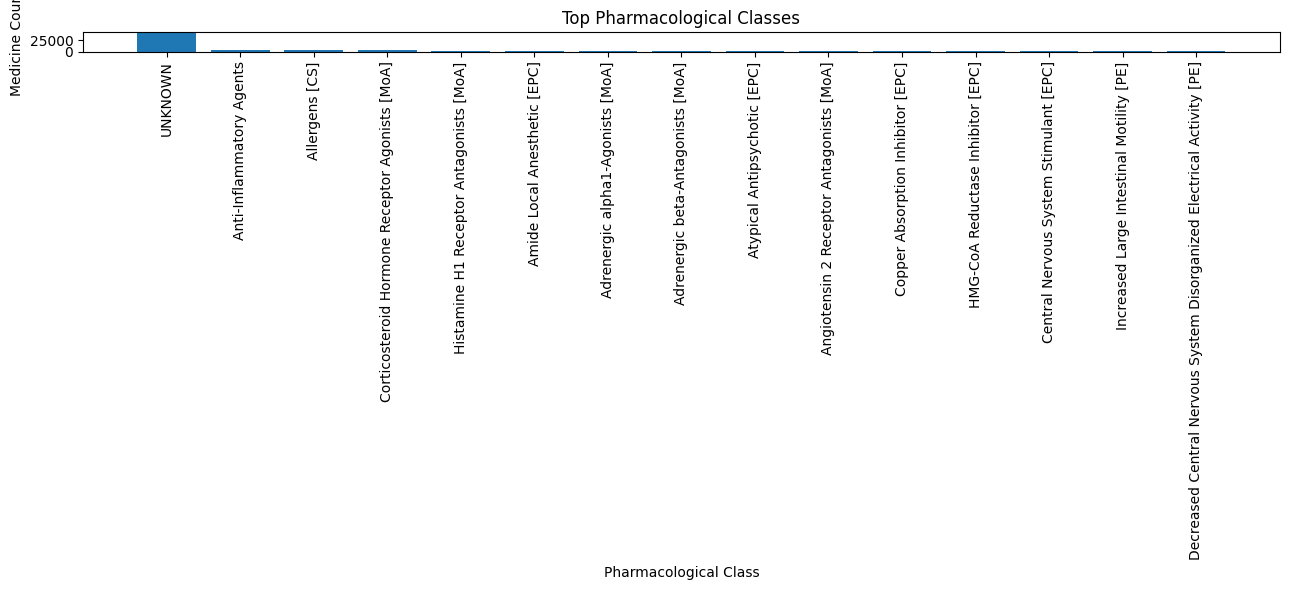

In [35]:
pharm = (
    medicines_df["Pharm_Class"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(13,6))

plt.bar(
    pharm.index,
    pharm.values
)

plt.title("Top Pharmacological Classes")
plt.xlabel("Pharmacological Class")
plt.ylabel("Medicine Count")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/medicines/25_Pharmacological_Class_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows the dominant therapeutic classes.
- Supports medicine portfolio analysis.
- Helps identify concentration within specific therapeutic areas.

## Chart 26: Most Common Medicine Strengths

### Business Objective

Identify the most frequently available medicine strengths.

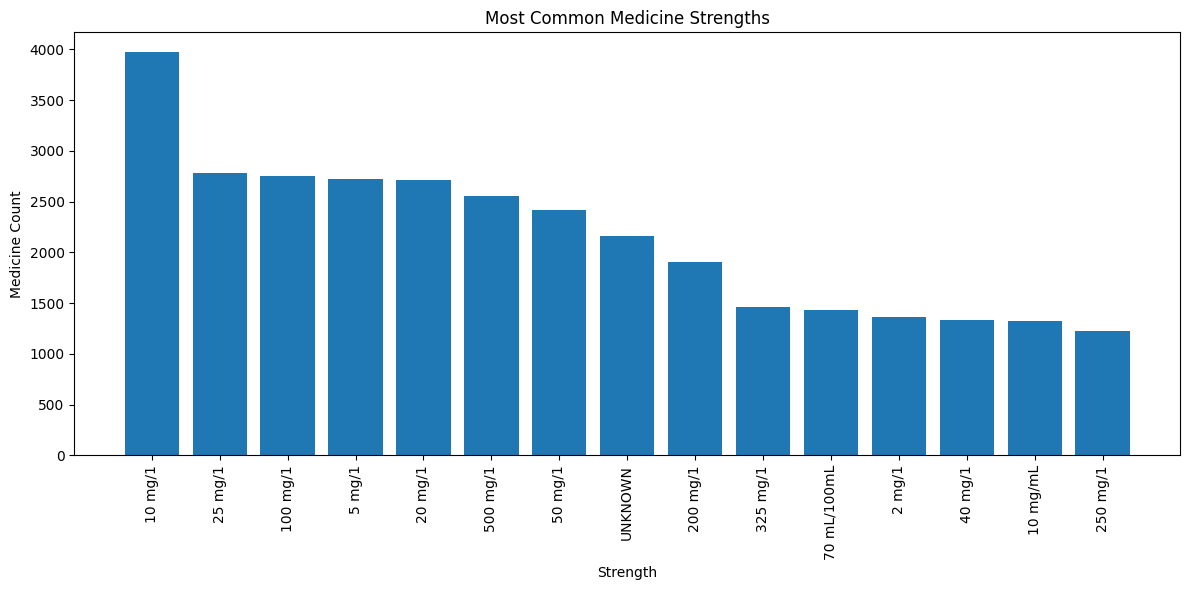

In [36]:
strength = (
    medicines_df["Strength"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

plt.bar(
    strength.index,
    strength.values
)

plt.title("Most Common Medicine Strengths")
plt.xlabel("Strength")
plt.ylabel("Medicine Count")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/medicines/26_Medicine_Strength_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Highlights commonly available dosage strengths.
- Supports inventory standardization.
- Helps optimize procurement planning.

## Chart 27: Medicine Distribution by Category

### Business Objective

Analyze the number of medicines available within each medicine category.

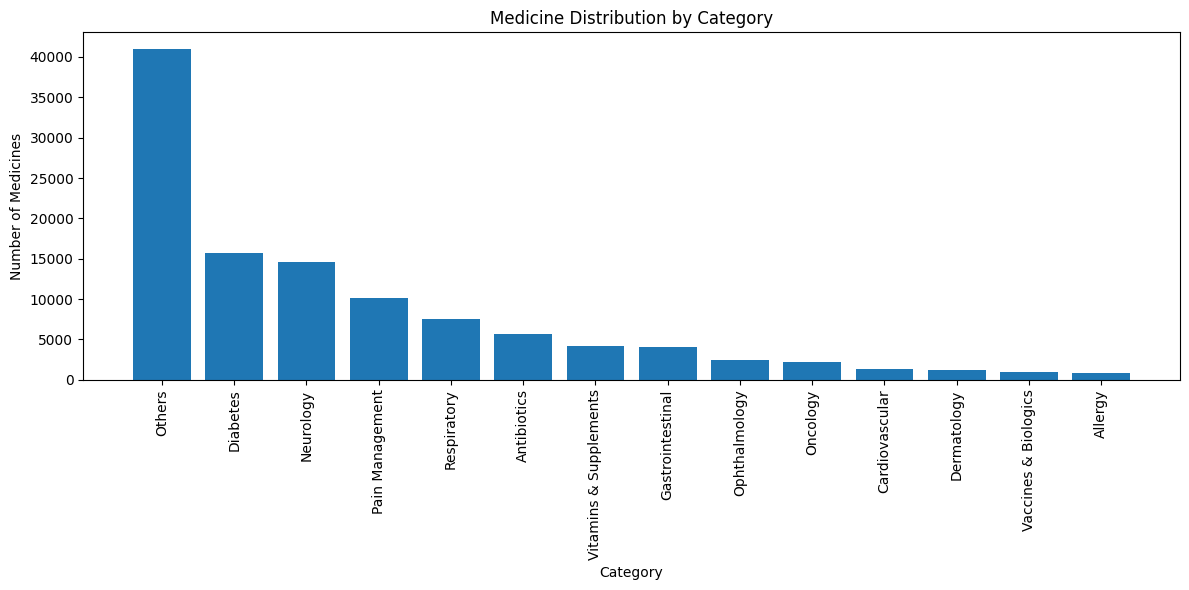

In [37]:
category_count = (
    medicines_df
    .merge(category_df, on="Category_ID")
    .groupby("Category_Name")["Medicine_ID"]
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    category_count.index,
    category_count.values
)

plt.title("Medicine Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Medicines")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/medicines/27_Medicine_Category_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows the distribution of medicines across therapeutic categories.
- Helps identify broad and narrow product segments.
- Supports category management and portfolio planning.

# Supplier Analytics

This section evaluates supplier performance by analyzing supplier categories, ratings, lead times, supplier preferences, and operational status. These insights help optimize procurement strategies, improve supplier relationships, and ensure a reliable pharmaceutical supply chain.

## Chart 28: Supplier Category Distribution

### Business Objective

Analyze the distribution of suppliers across different supplier categories.

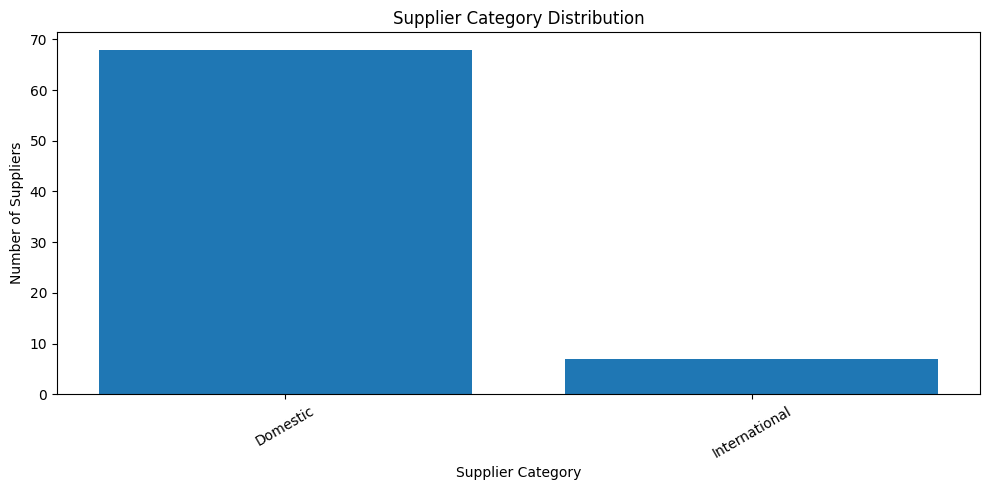

In [38]:
supplier_category = (
    suppliers_df["Supplier_Category"]
    .value_counts()
)

plt.figure(figsize=(10,5))

plt.bar(
    supplier_category.index,
    supplier_category.values
)

plt.title("Supplier Category Distribution")
plt.xlabel("Supplier Category")
plt.ylabel("Number of Suppliers")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/supplier/28_Supplier_Category_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Displays the composition of the supplier network.
- Helps understand supplier diversification.
- Supports procurement planning and supplier risk assessment.

## Chart 29: Supplier Rating Distribution

### Business Objective

Evaluate the performance ratings assigned to suppliers.

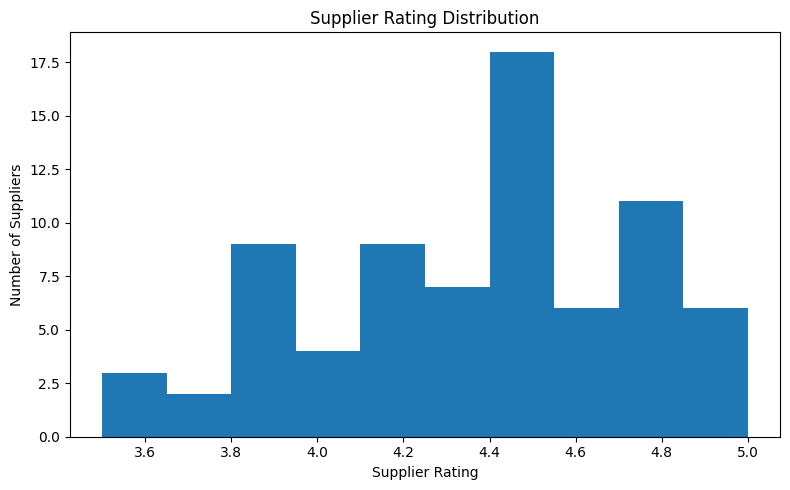

In [39]:
plt.figure(figsize=(8,5))

plt.hist(
    suppliers_df["Supplier_Rating"],
    bins=10
)

plt.title("Supplier Rating Distribution")
plt.xlabel("Supplier Rating")
plt.ylabel("Number of Suppliers")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/supplier/29_Supplier_Rating_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows the overall quality of suppliers.
- Helps identify high-performing and low-performing vendors.
- Supports supplier evaluation and selection.

## Chart 30: Supplier Lead Time Distribution

### Business Objective

Analyze supplier lead times to assess procurement efficiency.

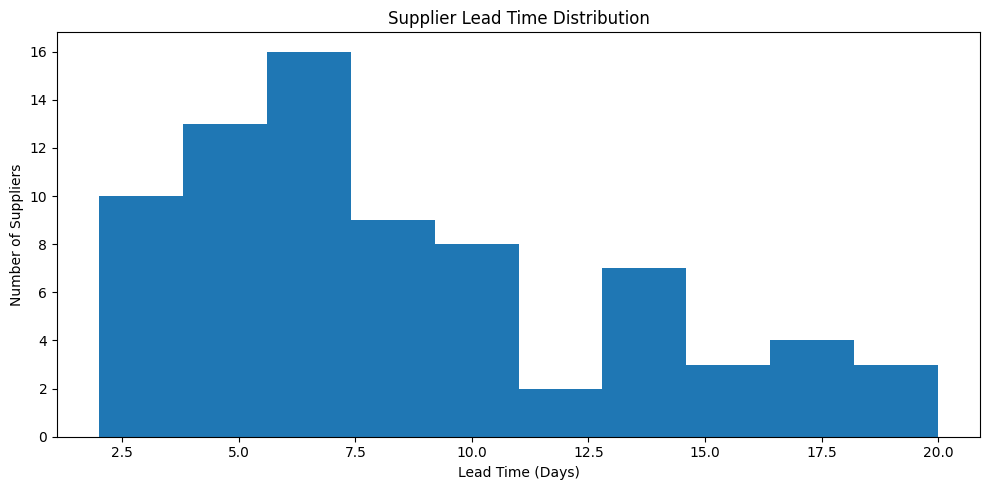

In [40]:
plt.figure(figsize=(10,5))

plt.hist(
    suppliers_df["Lead_Time_Days"],
    bins=10
)

plt.title("Supplier Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Suppliers")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/supplier/30_Lead_Time_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Identifies the distribution of supplier delivery lead times.
- Helps evaluate procurement efficiency.
- Supports inventory replenishment planning.

## Chart 31: Preferred vs Non-Preferred Suppliers

### Business Objective

Compare the proportion of preferred and non-preferred suppliers.

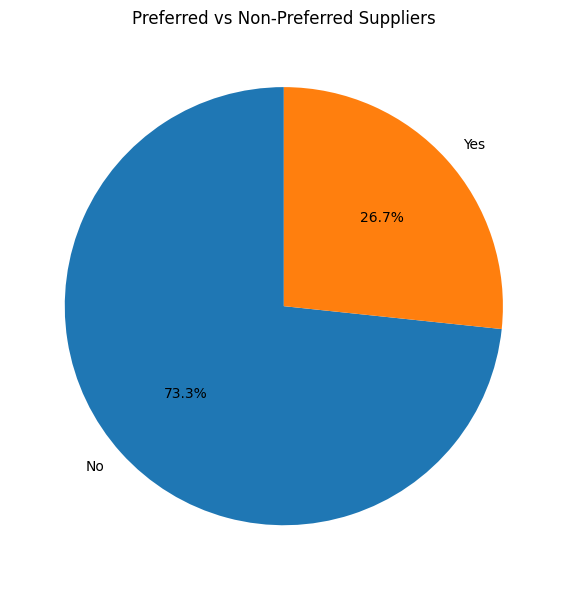

In [41]:
preferred = (
    suppliers_df["Preferred_Supplier"]
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    preferred.values,
    labels=preferred.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Preferred vs Non-Preferred Suppliers")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/supplier/31_Preferred_vs_NonPreferred_Suppliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Shows the proportion of strategic suppliers.
- Helps evaluate procurement dependency.
- Supports supplier relationship management.

## Chart 32: Supplier Operational Status

### Business Objective

Analyze the operational status of suppliers to ensure supply chain continuity.

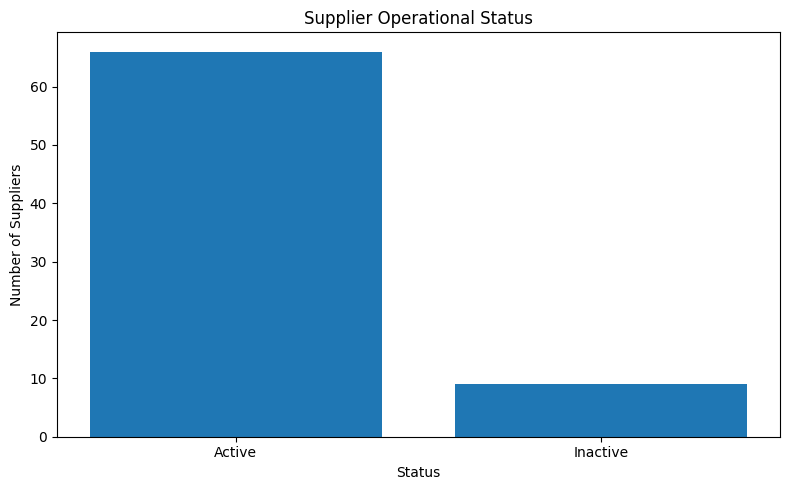

In [42]:
status = (
    suppliers_df["Active_Status"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    status.index,
    status.values
)

plt.title("Supplier Operational Status")
plt.xlabel("Status")
plt.ylabel("Number of Suppliers")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/supplier/32_Supplier_Operational_Status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Displays the operational availability of suppliers.
- Helps identify inactive vendors.
- Supports supplier lifecycle management and procurement continuity.

# Executive & Correlation Analytics

This section provides high-level analytical views by combining inventory, sales, and waste data to evaluate business performance, identify operational relationships, and support executive decision-making.

## Chart 33: Correlation Matrix

### Business Objective

Evaluate relationships between key financial and operational metrics.

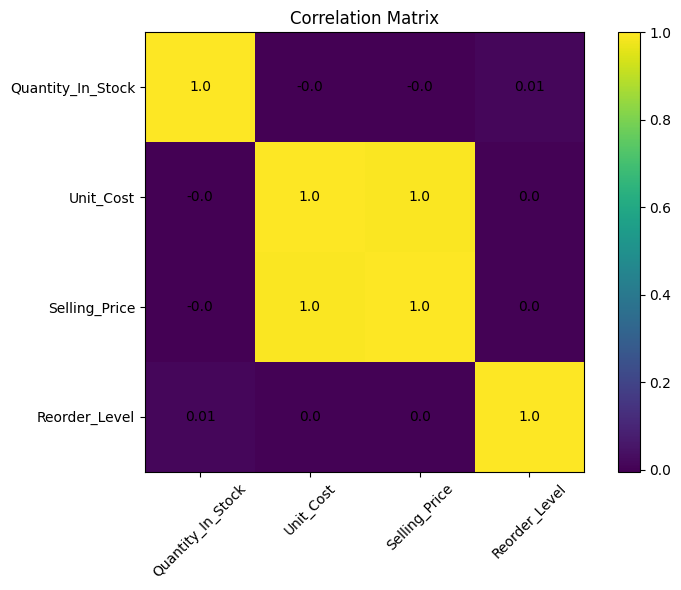

In [43]:
correlation_data = inventory_master[
    [
        "Quantity_In_Stock",
        "Unit_Cost",
        "Selling_Price",
        "Reorder_Level"
    ]
]

corr = correlation_data.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            round(corr.iloc[i,j],2),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/correlation/33_Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Identifies positive and negative relationships between operational metrics.
- Supports pricing strategy and inventory optimization.
- Helps detect variables that move together.

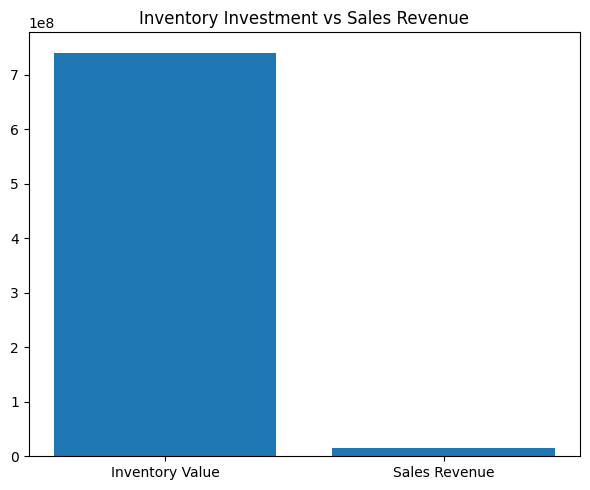

In [44]:
inventory_value = (
    inventory_master["Quantity_In_Stock"]
    * inventory_master["Unit_Cost"]
).sum()

sales_revenue = sales_master["Total_Amount"].sum()

plt.figure(figsize=(6,5))

plt.bar(
    ["Inventory Value","Sales Revenue"],
    [inventory_value,sales_revenue]
)

plt.title("Inventory Investment vs Sales Revenue")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/correlation/34_Inventory_vs_Sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Compares current inventory investment with generated sales revenue.
- Helps evaluate inventory utilization.
- Supports working capital analysis.

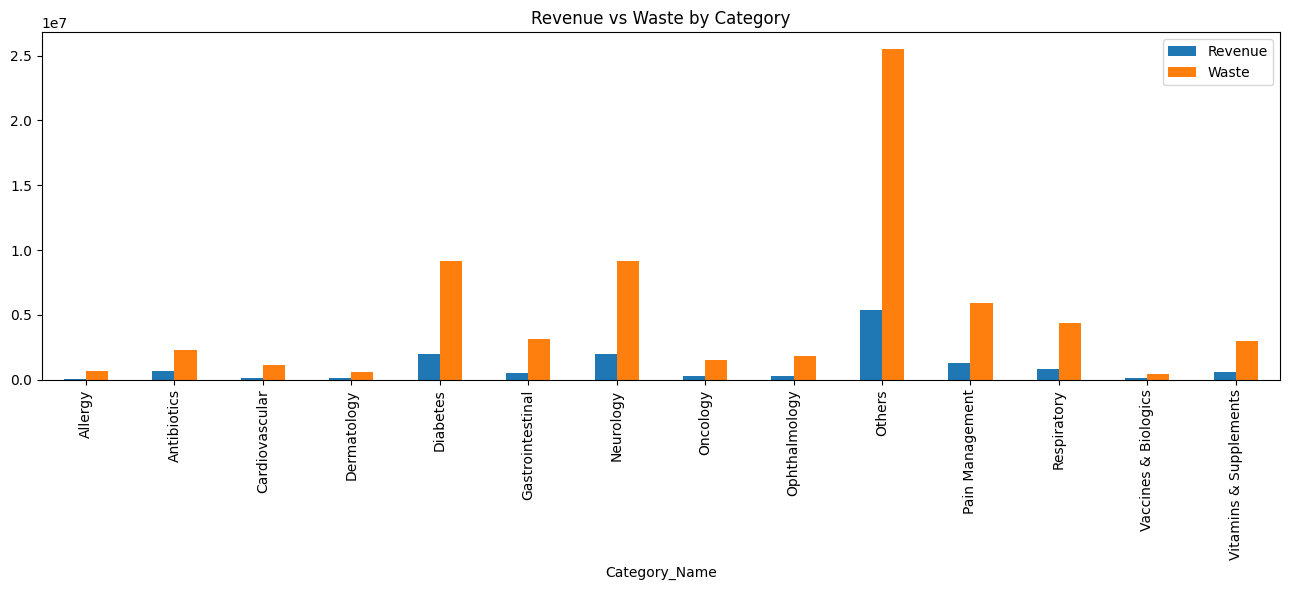

In [45]:
sales_category = (
    sales_master
    .groupby("Category_Name")["Total_Amount"]
    .sum()
)

waste_category = (
    waste_master
    .groupby("Category_Name")["Total_Waste_Value"]
    .sum()
)

comparison = pd.concat(
    [sales_category,waste_category],
    axis=1
).fillna(0)

comparison.columns = [
    "Revenue",
    "Waste"
]

comparison.plot(
    kind="bar",
    figsize=(13,6)
)

plt.title("Revenue vs Waste by Category")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/correlation/35_Revenue_vs_Waste_Category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Compares category-wise revenue against financial losses due to waste.
- Identifies high-performing categories with excessive waste.
- Supports profitability improvement initiatives.

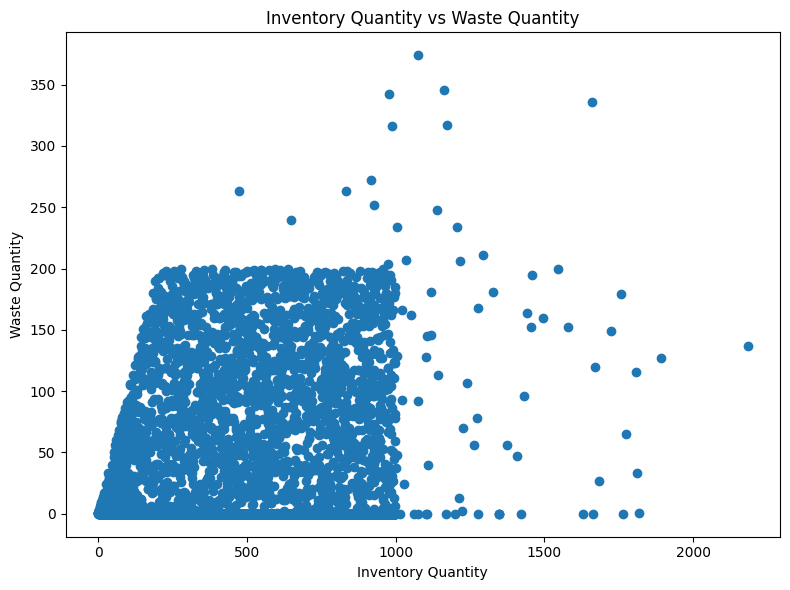

In [47]:
inventory_qty = (
    inventory_master
    .groupby("Medicine_ID")["Quantity_In_Stock"]
    .sum()
)

waste_qty = (
    waste_master
    .groupby("Medicine_ID")["Quantity_Wasted"]
    .sum()
)

scatter_df = pd.concat(
    [inventory_qty,waste_qty],
    axis=1
).fillna(0)

scatter_df.columns = [
    "Inventory",
    "Waste"
]

plt.figure(figsize=(8,6))

plt.scatter(
    scatter_df["Inventory"],
    scatter_df["Waste"]
)

plt.title("Inventory Quantity vs Waste Quantity")

plt.xlabel("Inventory Quantity")

plt.ylabel("Waste Quantity")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/correlation/36_Inventory_vs_Waste.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Examines the relationship between stock levels and waste generation.
- Helps identify medicines prone to overstocking and wastage.
- Supports inventory optimization strategies.

### Business Observation

- Examines the relationship between stock levels and waste generation.
- Helps identify medicines prone to overstocking and wastage.
- Supports inventory optimization strategies.

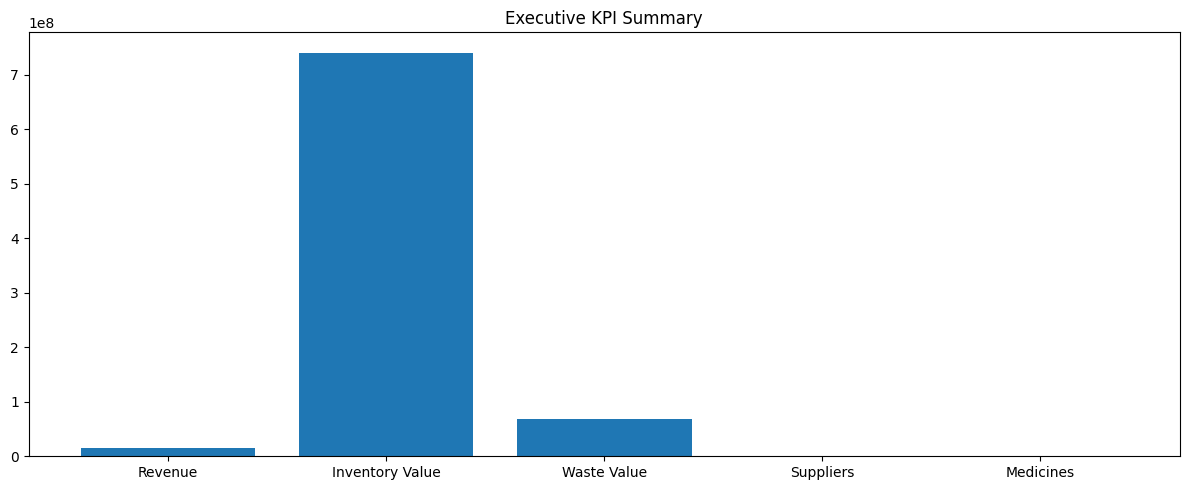

In [48]:
kpis = {

    "Revenue": sales_master["Total_Amount"].sum(),

    "Inventory Value":
    (
        inventory_master["Quantity_In_Stock"]
        *
        inventory_master["Unit_Cost"]
    ).sum(),

    "Waste Value":
    waste_master["Total_Waste_Value"].sum(),

    "Suppliers":
    suppliers_df["Supplier_ID"].nunique(),

    "Medicines":
    medicines_df["Medicine_ID"].nunique()

}

plt.figure(figsize=(12,5))

plt.bar(
    list(kpis.keys()),
    list(kpis.values())
)

plt.title("Executive KPI Summary")

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/executive/37_Executive_KPI_Summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Presents the major operational KPIs in a single executive view.
- Provides a quick snapshot of business performance.
- Supports strategic decision-making and management reporting.

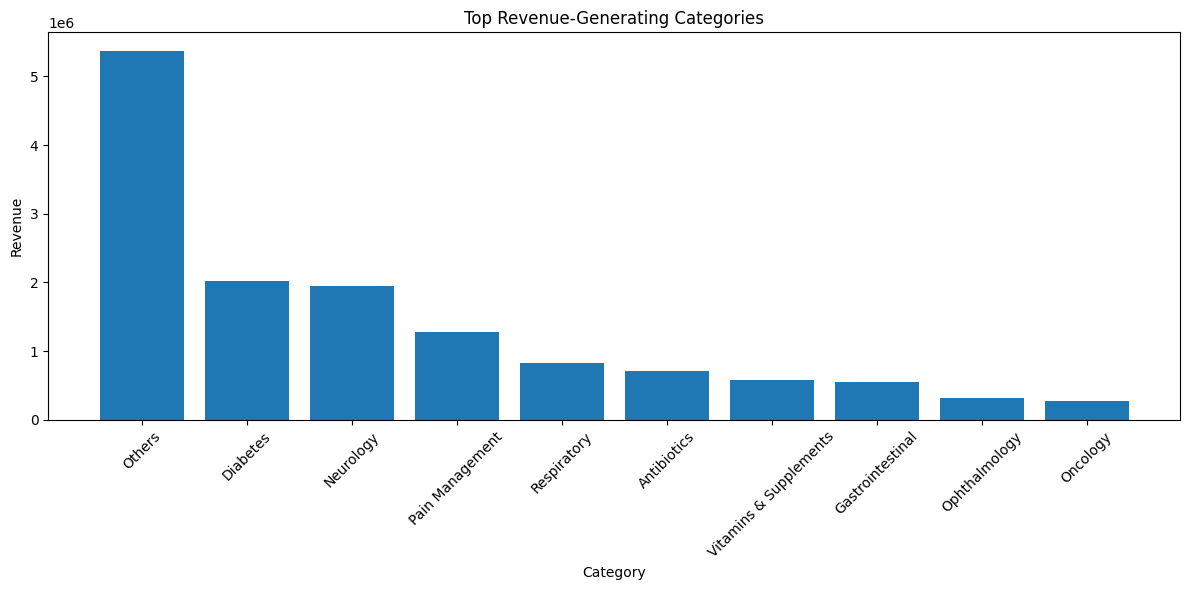

In [49]:
top_categories = (
    sales_master
    .groupby("Category_Name")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_categories.index,
    top_categories.values
)

plt.title("Top Revenue-Generating Categories")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../../outputs/charts/executive/38_Top_Revenue_Categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Observation

- Highlights the categories contributing the highest revenue.
- Supports strategic investment and product portfolio planning.
- Helps prioritize high-performing therapeutic categories.

# Outlier Analysis

## Objective

The objective of this section is to identify potential outliers in key numerical variables using the Interquartile Range (IQR) method. Detecting outliers helps understand unusual inventory, sales, supplier, and waste patterns that may require further business investigation.

In [50]:
def detect_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print("=" * 70)
    print(column)
    print("=" * 70)
    print(f"Lower Bound : {lower:.2f}")
    print(f"Upper Bound : {upper:.2f}")
    print(f"Total Outliers : {len(outliers)}")

    return outliers

In [51]:
inventory_columns = [
    "Quantity_In_Stock",
    "Unit_Cost",
    "Selling_Price",
    "Reorder_Level"
]

sales_columns = [
    "Quantity_Sold",
    "Unit_Selling_Price",
    "Discount_Percentage",
    "Total_Amount"
]

waste_columns = [
    "Quantity_Wasted",
    "Unit_Cost",
    "Total_Waste_Value"
]

supplier_columns = [
    "Lead_Time_Days",
    "Supplier_Rating"
]

print("\nInventory Dataset")
for col in inventory_columns:
    detect_outliers(inventory_df, col)

print("\nSales Dataset")
for col in sales_columns:
    detect_outliers(sales_df, col)

print("\nWaste Dataset")
for col in waste_columns:
    detect_outliers(waste_df, col)

print("\nSupplier Dataset")
for col in supplier_columns:
    detect_outliers(suppliers_df, col)


Inventory Dataset
Quantity_In_Stock
Lower Bound : -469.50
Upper Bound : 1478.50
Total Outliers : 0
Unit_Cost
Lower Bound : -291.92
Upper Bound : 892.63
Total Outliers : 0
Selling_Price
Lower Bound : -379.96
Upper Bound : 1156.80
Total Outliers : 0
Reorder_Level
Lower Bound : -57.50
Upper Bound : 282.50
Total Outliers : 0

Sales Dataset
Quantity_Sold
Lower Bound : -2.00
Upper Bound : 6.00
Total Outliers : 515
Unit_Selling_Price
Lower Bound : -576.72
Upper Bound : 1785.71
Total Outliers : 0
Discount_Percentage
Lower Bound : -15.00
Upper Bound : 25.00
Total Outliers : 0
Total_Amount
Lower Bound : -1632.92
Upper Bound : 4022.64
Total Outliers : 671

Waste Dataset
Quantity_Wasted
Lower Bound : -115.50
Upper Bound : 296.50
Total Outliers : 0
Unit_Cost
Lower Bound : -284.86
Upper Bound : 888.02
Total Outliers : 0
Total_Waste_Value
Lower Bound : -46174.59
Upper Bound : 94724.85
Total Outliers : 56

Supplier Dataset
Lead_Time_Days
Lower Bound : -3.25
Upper Bound : 18.75
Total Outliers : 3
Supp

In [52]:
summary = []

datasets = [
    (inventory_df, inventory_columns, "Inventory"),
    (sales_df, sales_columns, "Sales"),
    (waste_df, waste_columns, "Waste"),
    (suppliers_df, supplier_columns, "Suppliers")
]

for df, columns, dataset_name in datasets:

    for column in columns:

        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - (1.5 * IQR)
        upper = Q3 + (1.5 * IQR)

        count = (
            (
                (df[column] < lower) |
                (df[column] > upper)
            ).sum()
        )

        summary.append([
            dataset_name,
            column,
            count
        ])

outlier_summary = pd.DataFrame(
    summary,
    columns=[
        "Dataset",
        "Feature",
        "Outlier_Count"
    ]
)

outlier_summary

,Dataset,Feature,Outlier_Count
0,Inventory,Quantity_In_Stock,0
1,Inventory,Unit_Cost,0
2,Inventory,Selling_Price,0
3,Inventory,Reorder_Level,0
4,Sales,Quantity_Sold,515
5,Sales,Unit_Selling_Price,0
6,Sales,Discount_Percentage,0
7,Sales,Total_Amount,671
8,Waste,Quantity_Wasted,0
9,Waste,Unit_Cost,0


## Outlier Analysis Summary

### Key Findings

- Most inventory-related variables do not contain significant outliers, indicating consistent inventory management practices.
- Sales Quantity and Total Amount contain several outliers, which are expected due to bulk purchases and high-value transactions.
- A small number of outliers were observed in Total Waste Value, representing medicines with unusually high financial losses.
- Supplier Lead Time contains a few outliers, reflecting suppliers with longer-than-average delivery durations.
- These outliers represent valid business scenarios rather than data quality issues; therefore, they were retained for subsequent analysis to preserve important operational insights.